# Notebook 01 — Collecte des données

Objectif : télécharger les prix historiques des actions choisies et de l'indice CAC 40.

À la fin de ce notebook, on obtient :
- `data/raw/prix_actions.csv`

In [3]:
# TODO importer les bibliothèques
import os
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

os.makedirs("../data/brut", exist_ok=True)
os.makedirs("../data/obtenue", exist_ok=True)
os.makedirs("../figures", exist_ok=True)


## 1. Liste des actions

On choisit 15 actions françaises .


In [4]:
# TODO à faire par tareq
campanies = [
    "TTE.PA",   # TotalEnergies
    "SU.PA",    # Schneider Electric
    "MC.PA",    # LVMH
    "AI.PA",    # Air Liquide
    "SAN.PA",   # Sanofi
    "AIR.PA",   # Airbus
    "SAF.PA",   # Safran
    "BNP.PA",   # BNP Paribas
    "OR.PA",    # L'Oréal
    "CS.PA",    # AXA
    "DG.PA",    # Vinci
    "EL.PA",    # EssilorLuxottica
    "RMS.PA",   # Hermès
    "KER.PA",   # Kering
    "ACA.PA"    # Crédit Agricole
]

indice = "^FCHI"
all_campanies = campanies + [indice]

noms_actions = {
    "TTE.PA": "TotalEnergies",
    "SU.PA": "Schneider Electric",
    "MC.PA": "LVMH",
    "AI.PA": "Air Liquide",
    "SAN.PA": "Sanofi",
    "AIR.PA": "Airbus",
    "SAF.PA": "Safran",
    "BNP.PA": "BNP Paribas",
    "OR.PA": "L'Oréal",
    "CS.PA": "AXA",
    "DG.PA": "Vinci",
    "EL.PA": "EssilorLuxottica",
    "RMS.PA": "Hermès",
    "KER.PA": "Kering",
    "ACA.PA": "Crédit Agricole",
    "^FCHI": "CAC 40"
}

## 2. Téléchargement des données



In [5]:
# TODO à faire par tareq
data = yf.download(
    all_campanies,
    start="2020-01-01",
    end="2025-12-31",
    auto_adjust=True,
    progress=True
)

data.head()

[*********************100%***********************]  16 of 16 completed


Price          Close                                                          \
Ticker        ACA.PA      AI.PA      AIR.PA     BNP.PA      CS.PA      DG.PA   
Date                                                                           
2020-01-02  8.961941  93.452423  122.495926  37.874340  18.182152  79.617828   
2020-01-03  8.907563  93.157387  122.973000  37.421936  18.189293  79.123413   
2020-01-06  8.819201  92.530441  122.440887  37.238148  17.950054  78.724686   
2020-01-07  8.798810  92.124756  121.101433  37.224007  18.060747  78.182411   
2020-01-08  8.839593  92.198524  123.284920  37.308838  18.053604  79.681633   

Price                                                       ...  Volume  \
Ticker           EL.PA      KER.PA       MC.PA       OR.PA  ...   EL.PA   
Date                                                        ...           
2020-01-02  122.481560  514.596558  380.116333  242.358582  ...  533765   
2020-01-03  122.078354  517.092285  380.070953  242.083344  ...  515016   
2020-01-06  121.943954  508.400818  376.488861  241.257751  ...  567758   
2020-01-07  122.795143  513.133789  377.259674  238.138840  ...  592386   
2020-01-08  124.452713  513.994263  379.798889  239.606583  ...  396153   

Price                                                                         \
Ticker      KER.PA   MC.PA   OR.PA RMS.PA  SAF.PA   SAN.PA    SU.PA   TTE.PA   
Date                                                                           
2020-01-02  178651  347226  351300  42679  727750  1720684  1084445  4326276   
2020-01-03  159019  291716  292884  33911  558276  1534465   971960  4960724   
2020-01-06  176511  363953  367820  44451  713375  2356637  1080758  7596924   
2020-01-07  201861  363885  508141  50766  730793  1975503  1025424  5380020   
2020-01-08  201239  360741  431996  34952  762013  1718950  1124353  4922510   

Price                 
Ticker         ^FCHI  
Date                  
2020-01-02  63958300  
2020-01-03  60488000  
2020-01-06  69063700  
2020-01-07  69593800  
2020-01-08  71431600  

[5 rows x 80 columns]

## 3. Extraction des prix de clôture



In [6]:
# TODO faire par tareq
prix = data["Close"].copy()

# On supprime les lignes complètement vides si elles existent.
prix = prix.dropna(how="all")

# On sauvegarde les données brutes.
prix.to_csv("../data/brut/prix_actions.csv")

prix.head()

Ticker,ACA.PA,AI.PA,AIR.PA,BNP.PA,CS.PA,DG.PA,EL.PA,KER.PA,MC.PA,OR.PA,RMS.PA,SAF.PA,SAN.PA,SU.PA,TTE.PA,^FCHI
Date,,,,,,,,,,,,,,,,
2020-01-02,8.961941,93.452423,122.495926,37.874340,18.182152,79.617828,122.481560,514.596558,380.116333,242.358582,634.294495,132.262634,71.409302,81.937675,33.182529,6041.500000
2020-01-03,8.907563,93.157387,122.973000,37.421936,18.189293,79.123413,122.078354,517.092285,380.070953,242.083344,638.453735,132.647110,71.852547,81.726372,33.558884,6044.160156
2020-01-06,8.819201,92.530441,122.440887,37.238148,17.950054,78.724686,121.943954,508.400818,376.488861,241.257751,633.160095,131.157242,72.303711,81.620705,34.044853,6013.589844
2020-01-07,8.798810,92.124756,121.101433,37.224007,18.060747,78.182411,122.795143,513.133789,377.259674,238.138840,641.100708,132.358749,72.050423,81.286140,33.822121,6012.350098
2020-01-08,8.839593,92.198524,123.284920,37.308838,18.053604,79.681633,124.452713,513.994263,379.798889,239.606583,646.772461,132.166504,72.295784,81.497452,33.909863,6031.000000


## 4. Vérification rapide

On vérifie les dimensions et les valeurs manquantes.


In [7]:
# TODO faire par karim
print("Nombre de lignes et colonnes :", prix.shape)
print("\nValeurs manquantes par colonne :")
print(prix.isna().sum())

Nombre de lignes et colonnes : (1537, 16)

Valeurs manquantes par colonne :
Ticker
ACA.PA    0
AI.PA     0
AIR.PA    0
BNP.PA    0
CS.PA     0
DG.PA     0
EL.PA     0
KER.PA    0
MC.PA     0
OR.PA     0
RMS.PA    0
SAF.PA    0
SAN.PA    0
SU.PA     0
TTE.PA    0
^FCHI     0
dtype: int64


## 5. Visualisation rapide des prix normalisés



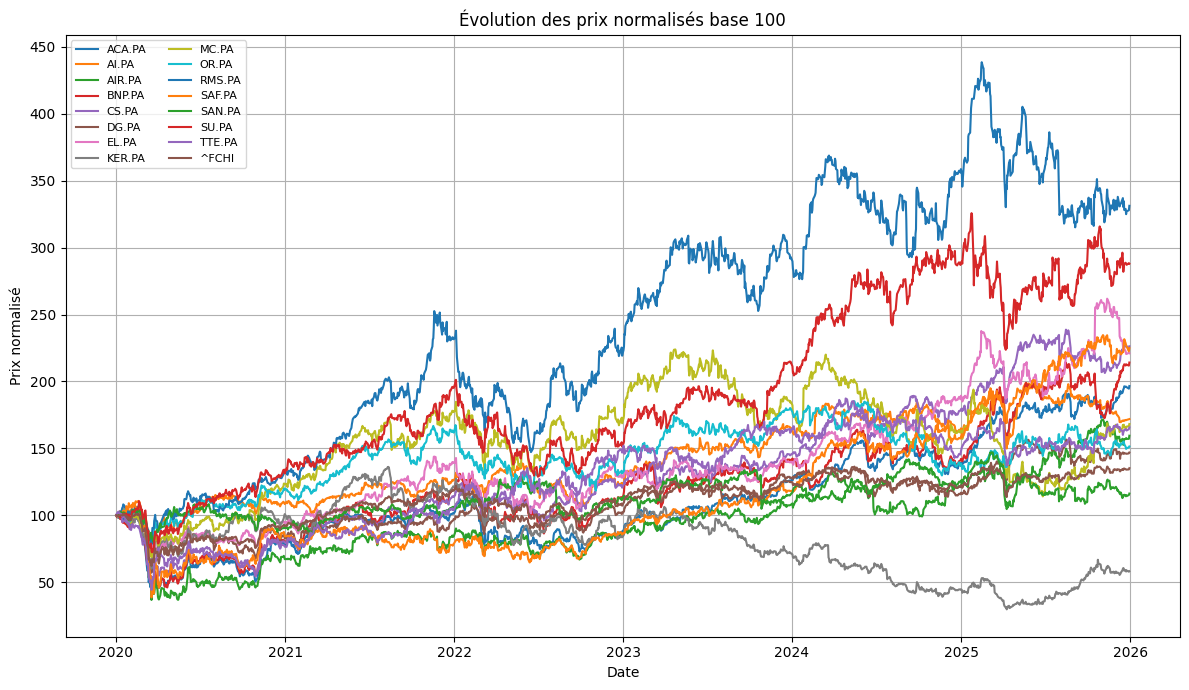

In [9]:
# TODO faire par karim
prix_normalises = prix / prix.iloc[0] * 100

plt.figure(figsize=(12, 7))
for col in prix_normalises.columns:
    plt.plot(prix_normalises.index, prix_normalises[col], label=col)

plt.title("Évolution des prix normalisés base 100")
plt.xlabel("Date")
plt.ylabel("Prix normalisé")
plt.legend(fontsize=8, ncol=2)
plt.grid(True)
plt.tight_layout()
plt.savefig("../figures/evolution_prix_normalises.png", dpi=300)
plt.show()